# Exercise: EDA on Penguins

In this notebook exercise, we will conduct simple EDA steps on the popular penguins dataset.

# Step 1 Understand the Features

You can find information about this dataset here: https://www.kaggle.com/datasets/parulpandey/palmer-archipelago-antarctica-penguin-data

**Question: in your own words**:

1. describe each feature
2. mention its type (numeric or categorical)
3. write its name in Arabic

Please use a Markdown cell to write your answer:

INSERT ANSWER HERE : Musaad Fahad Alanazi

Hint: you can attach an image to illustrate what the features are.

<img src="https://github.com/allisonhorst/palmerpenguins/raw/main/man/figures/culmen_depth.png" width="400">

## Load the dataset

The following will load the dataset automatically.

In [ ]:
import seaborn as sns

In [ ]:
# You don't have to download the dataset
# the following will download it for you
df = sns.load_dataset('penguins')

Dataset source: https://github.com/allisonhorst/palmerpenguins

## Step 2: look at the DataFrame

- Have a look at the columns and their values (`head`, `sample`, `tail`)
- How many rows and columns do you have? (`df.shape`)
- Look at the full technical information (`info`)

In [ ]:
# INSERT CODE HERE
df.head()


In [ ]:
df.sample(5)

In [ ]:
df.tail()

In [ ]:
df.shape

In [ ]:
df.info()

# Step 3

#### Data types conversion
- We shall convert the string types to `category` to preserve memory
- numeric types can be stored in less precision: `float32`

In [ ]:
mem_usage_before = df.memory_usage(deep=True)

In [ ]:
# convert categotical types
df['species'] = df['species'].astype('category')
df['island'] = df['island'].astype('category')
df['sex'] = df['sex'].astype('category')

In [ ]:
# convert numerical types
mem_usage_before = df.memory_usage(deep=True).sum()
df['bill_depth_mm'] = df['bill_depth_mm'].astype('float32')
df['bill_length_mm'] = df['bill_length_mm'].astype('float32')
df['flipper_length_mm'] = df['flipper_length_mm'].astype('float32')
df['body_mass_g'] = df['body_mass_g'].astype('float32')
# ...?
# ...?

Calculate memory saved after type conversion

In [ ]:
# mem_usage_after = ...?
mem_usage_before = df.memory_usage(deep=True).sum()

In [ ]:
print('memory saved:', (mem_usage_before - mem_usage_after).sum() // 1024, 'KB')

# Step 4

#### Detect inconsistency in categorical values

The categorical columns should be checked for any inconsistencies. For example. We look for lowercase, uppercase, or inconsistent use of codes (e.g., "M", "F") with non-codes (e.g., "Male", "Female")  in the `sex` column.

- hint: use `.unique()` to check the number of unique values in a column
- you can also use: `.value_counts()` to check the frequency of each value in a column

In [33]:
print(df['species'].unique())
print(df['island'].unique())
print(df['sex'].unique())

['Adelie', 'Chinstrap', 'Gentoo']
Categories (3, str): ['Adelie', 'Chinstrap', 'Gentoo']
['Torgersen', 'Biscoe', 'Dream']
Categories (3, str): ['Biscoe', 'Dream', 'Torgersen']
['Male', 'Female', NaN]
Categories (2, str): ['Female', 'Male']


# Step 5: Univariate Analysis

- Separate numerical from categorical columns (hint; use `df.select_dtypes()`)
- Look at the statistical information for each:
    - `df_num.describe().T`
    - `df_cat.describe().T`

In [32]:
# INSERT CODE HERE
df_num = df.select_dtypes(include=['number'])
df_cat = df.select_dtypes(include=['category'])

print(df_num.describe().T)
print(df_cat.describe().T)

                   count         mean         std          min          25%  \
bill_length_mm     342.0    43.921932    5.459584    32.099998    39.224998   
bill_depth_mm      342.0    17.151171    1.974793    13.100000    15.600000   
flipper_length_mm  342.0   200.915207   14.061714   172.000000   190.000000   
body_mass_g        342.0  4201.754395  801.954529  2700.000000  3550.000000   

                           50%          75%          max  
bill_length_mm       44.450001    48.500000    59.599998  
bill_depth_mm        17.299999    18.700001    21.500000  
flipper_length_mm   197.000000   213.000000   231.000000  
body_mass_g        4050.000000  4750.000000  6300.000000  
        count unique     top freq
species   344      3  Adelie  152
island    344      3  Biscoe  168
sex       333      2    Male  168


Use charts to plot `value_counts()` categorical variables:
1. plot `species` using bar plot
1. plot `island` using pie chart
1. plot `sex` using horizontal bar plot

<Axes: xlabel='species'>

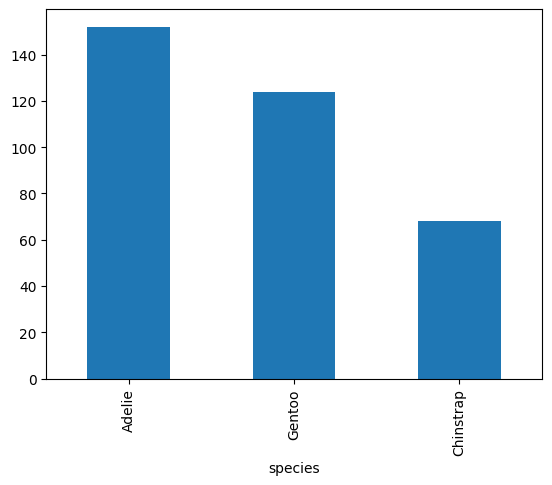

In [42]:
# INSERT CODE HERE
import matplotlib.pyplot as plt
species = df['species'].value_counts()
island = df['island'].value_counts()
sex = df['sex'].value_counts()

species.plot(kind='bar')



<Axes: >

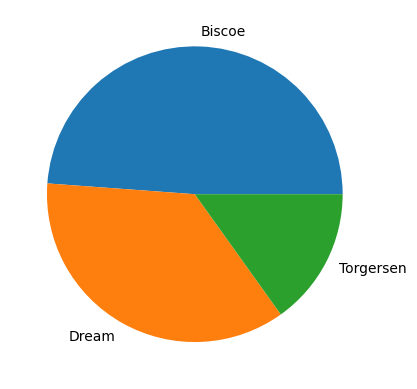

In [43]:
island.plot(kind='pie')


<Axes: ylabel='Frequency'>

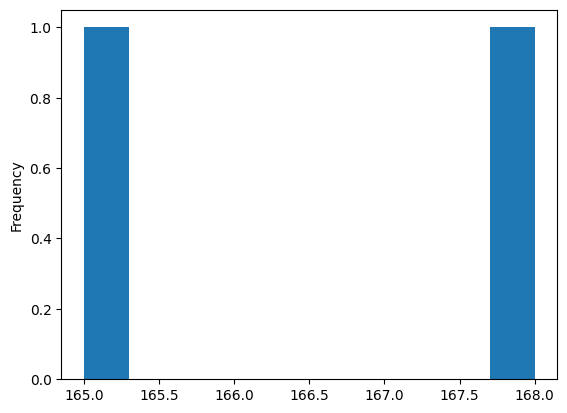

In [44]:
sex.plot(kind='hist')


Plot numerical variables:

1. Boxplot: `bill_length_mm`
1. Histogram: `bill_depth_mm`
1. Boxplot: `flipper_length_mm`
1. Histogram: `body_mass_g`

In [ ]:
# INSERT CODE HERE

## Step 6: Outlier detection

Use both methods to mark outliers, for at least one numerical column (e.g. `body_mass_g` or `bill_length_mm`):

1. Z-score method
2. IQR method

In [ ]:
# INSERT CODE HERE

## Step 7: Bivariate Analysis

#### Correlation between numerical features

Let's find out if there is any correlation between numerical features.

- Hint: you can use the `df.corr()` to find the correlation matrix.
- Hint: you can use `sns.heatmap()` to plot the correlation matrix
- Hint: you can use `sns.pairplot()` to visualize relationships.

In [ ]:
# INSERT CODE HERE

Question: Write down your observations based on the correlation heatmap.

**Observations:**

INSERT ANSWER HERE

### Feature Engineering

- We might try adding the feature `bill_size` which is the product of `bill_length` and `bill_depth` to see if it has any significance in the model.
- We might also try `bill_ratio` which is the ratio of `bill_length` to `bill_depth` to see if it has any significance in the model.

In [ ]:
# INSERT CODE HERE

Let's look at the correlation to see whether the newly created features are better.

1. Compute the correlation matrix
1. Select the `'body_mass_g'` column, sort it, and plot it using horizontal bar plot

In [ ]:
# INSERT CODE HERE
# This plots the correlation values for a specific column
# which is usually what we are interested in

# corr['body_mass_g'].sort_values().plot.barh()